# 基本 Seaborn 設定：讓統計圖表更快、更一致、更容易讀

記帳 App、運動手環、外送紀錄與通勤紀錄都有共同問題：資料很多，但我們真正想知道的通常是「誰比較高」、「是否有規律」、「不同群組有沒有差異」。Seaborn 能把表格欄位直接對應到顏色、圖形與子圖，讓統計圖表更容易寫，也更容易保持一致。

## 安裝與匯入

若環境尚未安裝套件，可在 Notebook 新增一格執行：

```python
%pip install seaborn pandas matplotlib
```

`%pip` 會安裝到目前 Notebook 使用的 Python 環境。安裝後若仍無法匯入，請重新啟動 Kernel。

社群慣例把：

- `seaborn` 簡寫成 `sns`
- `pandas` 簡寫成 `pd`
- `matplotlib.pyplot` 簡寫成 `plt`

這些只是較短的別名，不是不同套件。


In [1]:
%pip install seaborn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import seaborn as sns
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print(f"Seaborn 版本：{sns.__version__}")
print(f"Pandas 版本：{pd.__version__}")
print(f"Matplotlib 版本：{matplotlib.__version__}")


Seaborn 版本：0.13.2
Pandas 版本：3.0.5
Matplotlib 版本：3.11.2


## Seaborn、Matplotlib、Pandas 如何合作？

可以把做圖想成開一家便當店：

- **Pandas** 像整理食材的人：讀取、清理、篩選與整理表格。
- **Seaborn** 像懂搭配的主廚：知道數值與類別資料適合怎麼比較，能快速產生有統計意義的圖。
- **Matplotlib** 像廚房與餐具：負責底層畫布、座標軸、文字、尺寸與輸出。

Seaborn 是建立在 Matplotlib 上面的高階工具，因此兩者不是二選一。常見流程是：

```python
fig, ax = plt.subplots()             # Matplotlib 準備畫布
sns.scatterplot(data=df, x=..., y=..., ax=ax)  # Seaborn 畫資料
ax.set_title(...)                    # Matplotlib 微調
```

Seaborn 最大特色是「知道欄位名稱」。不用手動拆出很多串列，只要交給它一張 DataFrame，再說哪一欄是 x、哪一欄是 y。


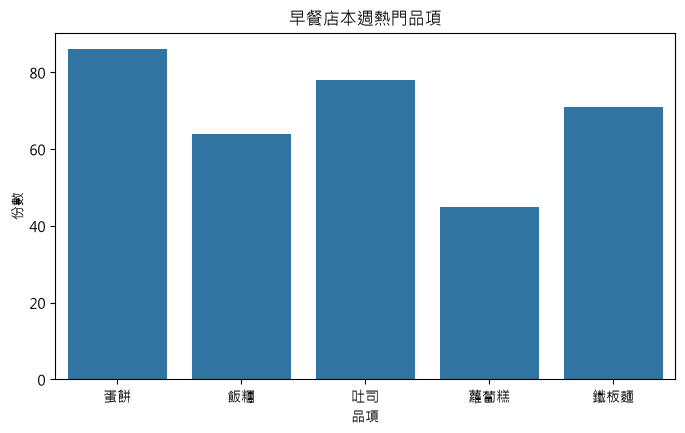

In [18]:
# 建立第一份生活資料：早餐店一週銷量
breakfast_df = pd.DataFrame({
    "品項": ["蛋餅", "飯糰", "吐司", "蘿蔔糕", "鐵板麵"],
    "份數": [86, 64, 78, 45, 71],
})

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(data=breakfast_df, x="品項", y="份數", ax=ax) 
    # ax.bar(breakfast_df["品項"], breakfast_df["份數"])
    # Seaborn 的優勢是可以直接指定「欄位名稱」
    ax.set_title("早餐店本週熱門品項")
    plt.show()

# - `data=breakfast_df`：資料來自哪張表。
# - `x="品項"`：水平位置使用「品項」欄。
# - `y="份數"`：長條高度使用「份數」欄。
# - `ax=ax`：把圖畫到指定的 Axes。


## 為什麼 Seaborn 喜歡「長格式」資料？

長格式可以想成「每一列是一筆觀察紀錄」。例如每天、每種交通方式的通勤時間，各自占一列。

| 日期 | 交通方式 | 分鐘 |
|---|---|---:|
| 週一 | 公車 | 42 |
| 週一 | 捷運 | 31 |
| 週二 | 公車 | 48 |

相對的寬格式可能把「公車」與「捷運」拆成兩欄。寬格式方便人眼閱讀，但當我們想用顏色代表交通方式時，長格式更自然，因為「交通方式」本身就是一個欄位。

Seaborn 所謂的**語意映射**，就是把欄位的意義映射成視覺：

- `x`：水平位置
- `y`：垂直位置
- `hue`：顏色
- `style`：線型或標記形狀
- `size`：點或線的大小

這套觀念比背函式名稱更重要。


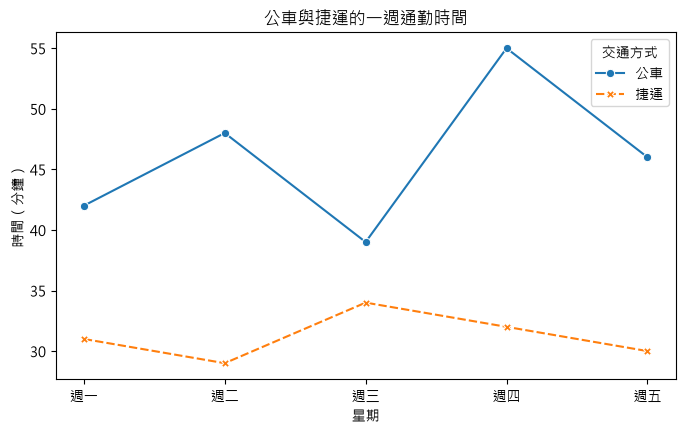

In [19]:
commute_df = pd.DataFrame({
    "星期": ["週一", "週二", "週三", "週四", "週五"] * 2,
    "交通方式": ["公車"] * 5 + ["捷運"] * 5,
    "分鐘": [42, 48, 39, 55, 46, 31, 29, 34, 32, 30],
})

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.lineplot(
        data=commute_df,       # 指定要使用的 DataFrame
        x="星期",              # x 軸使用「星期」欄位
        y="分鐘",              # y 軸使用「分鐘」欄位
        hue="交通方式",        # 根據「交通方式」使用不同顏色區分折線
        style="交通方式",      # 根據「交通方式」使用不同線條與標記樣式
        markers=True,          # 顯示每個資料點的標記
        dashes=True,           # 不同交通方式可使用不同的實線、虛線樣式
        ax=ax                  # 將圖畫在指定的 Matplotlib Axes 上
    )
    ax.set_title("公車與捷運的一週通勤時間")
    ax.set_ylabel("時間（分鐘）")
    plt.show()


同一欄「交通方式」同時交給 `hue` 和 `style`，讓兩組資料不只顏色不同，線型與標記也不同。即使黑白列印或觀眾不易分辨顏色，仍有第二條辨認線索。
